# 🛒 Retail Sales Analysis
## Notebook 2 — Merging & Feature Engineering

**Цель:** объединить все таблицы в единый датасет, создать признаки из даты, сформировать таблицы чеков, клиентов и товаров для дальнейшего анализа.

---
## 1. Импорт библиотек и загрузка очищенных данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')

print('Библиотеки загружены ✅')

Библиотеки загружены ✅


In [ ]:

sales      = pd.read_csv('sales_clean.csv', parse_dates=['SalesDate'])

# Исходные таблицы
customers  = pd.read_csv('customers.csv')
products   = pd.read_csv('products.csv')
categories = pd.read_csv('categories.csv')
cities     = pd.read_csv('cities.csv')
countries  = pd.read_csv('countries.csv')

print('Все таблицы загружены ✅')
print(f'sales:      {sales.shape}')
print(f'customers:  {customers.shape}')
print(f'products:   {products.shape}')
print(f'categories: {categories.shape}')

Все таблицы загружены ✅
sales:      (6690599, 11)
customers:  (98759, 6)
products:   (452, 9)
categories: (11, 2)


In [ ]:
for name, df in [('sales', sales), ('customers', customers),
                 ('products', products), ('categories', categories)]:
    print(f'{name}: {list(df.columns)}')

sales: ['SalesID', 'SalesPersonID', 'CustomerID', 'ProductID', 'Quantity', 'Discount', 'TotalPrice', 'SalesDate', 'TransactionNumber', 'Price', 'Revenue']
customers: ['CustomerID', 'FirstName', 'MiddleInitial', 'LastName', 'CityID', 'Address']
products: ['ProductID', 'ProductName', 'Price', 'CategoryID', 'Class', 'ModifyDate', 'Resistant', 'IsAllergic', 'VitalityDays']
categories: ['CategoryID', 'CategoryName']


---
## 2. Объединение таблиц

> **Логика:** sales → + customers (по CustomerID) → + products (по ProductID, только новые поля) → + categories (по CategoryID)

In [ ]:
products_slim = products[['ProductID', 'ProductName', 'CategoryID', 'Class',
                           'Resistant', 'IsAllergic', 'VitalityDays']]

df = sales.merge(customers, on='CustomerID', how='left')
df = df.merge(products_slim, on='ProductID', how='left')
df = df.merge(categories, on='CategoryID', how='left')
df = df.merge(cities[['CityID', 'CityName', 'CountryID']], on='CityID', how='left')
df = df.merge(countries[['CountryID', 'CountryName']], on='CountryID', how='left')

print(f'Итоговый датасет: {df.shape}')
print(f'Столбцы: {list(df.columns)}')

Итоговый датасет: (6690599, 26)
Столбцы: ['SalesID', 'SalesPersonID', 'CustomerID', 'ProductID', 'Quantity', 'Discount', 'TotalPrice', 'SalesDate', 'TransactionNumber', 'Price', 'Revenue', 'FirstName', 'MiddleInitial', 'LastName', 'CityID', 'Address', 'ProductName', 'CategoryID', 'Class', 'Resistant', 'IsAllergic', 'VitalityDays', 'CategoryName', 'CityName', 'CountryID', 'CountryName']


---
## 3. Проверка результата объединения

> После объединения таблиц я получила единую таблицу транзакций, где каждая строка содержит информацию о продаже, клиенте, товаре и категории.

In [5]:
display(df.head(3))

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Price,Revenue,FirstName,MiddleInitial,LastName,CityID,Address,ProductName,CategoryID,Class,Resistant,IsAllergic,VitalityDays,CategoryName,CityName,CountryID,CountryName
0,1,6,27039,381,7,0.00,0.00,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,44.23,309.64,Susan,V,Green,54,826 Rocky Second Freeway,Vaccum Bag 10x13,1,High,Unknown,Unknown,41.00,Confections,Albuquerque,32,United States
1,2,16,25011,61,7,0.00,0.00,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,62.55,437.82,Telly,W,Pollard,71,334 Cowley Street,Sardines,8,Low,Durable,False,90.00,Grain,Phoenix,32,United States
2,3,13,94024,23,24,0.00,0.00,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,79.02,1896.44,Jon,K,Rangel,2,537 First St.,Crab - Imitation Flakes,11,Medium,Durable,True,0.00,Produce,Buffalo,32,United States


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6690599 entries, 0 to 6690598
Data columns (total 26 columns):
 #   Column             Dtype         
---  ------             -----         
 0   SalesID            int64         
 1   SalesPersonID      int64         
 2   CustomerID         int64         
 3   ProductID          int64         
 4   Quantity           int64         
 5   Discount           float64       
 6   TotalPrice         float64       
 7   SalesDate          datetime64[us]
 8   TransactionNumber  str           
 9   Price              float64       
 10  Revenue            float64       
 11  FirstName          str           
 12  MiddleInitial      str           
 13  LastName           str           
 14  CityID             int64         
 15  Address            str           
 16  ProductName        str           
 17  CategoryID         int64         
 18  Class              str           
 19  Resistant          str           
 20  IsAllergic         str           
 

In [7]:
print('Пропуски после merge:')
missing = df.isnull().sum()
display(missing[missing > 0].rename('missing'))

Пропуски после merge:


MiddleInitial    66501
Name: missing, dtype: int64

---
## 4. Создание признаков из даты

In [8]:
df['SalesDate'] = pd.to_datetime(df['SalesDate'])

df['year']        = df['SalesDate'].dt.year
df['month']       = df['SalesDate'].dt.month
df['day']         = df['SalesDate'].dt.day
df['day_of_week'] = df['SalesDate'].dt.day_name()
df['quarter']     = df['SalesDate'].dt.quarter
df['week']        = df['SalesDate'].dt.isocalendar().week.astype(int)

print('Временные признаки добавлены ✅')
display(df[['SalesDate', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week']].head(5))

Временные признаки добавлены ✅


,SalesDate,year,month,day,day_of_week,quarter,week
0,2018-02-05 07:38:25.430,2018,2,5,Monday,1,6
1,2018-02-02 16:03:31.150,2018,2,2,Friday,1,5
2,2018-05-03 19:31:56.880,2018,5,3,Thursday,2,18
3,2018-04-07 14:43:55.420,2018,4,7,Saturday,2,14
4,2018-02-12 15:37:03.940,2018,2,12,Monday,1,7


---
## 6. Создание таблицы чеков

> Я сгруппировала данные по номеру транзакции, чтобы получить уровень чека: сумма чека, количество товаров и разнообразие категорий.

In [11]:
checks = df.groupby('TransactionNumber').agg(
    customer_id      = ('CustomerID',        'first'),
    check_date       = ('SalesDate',         'first'),
    check_revenue    = ('Revenue',           'sum'),
    total_quantity   = ('Quantity',          'sum'),
    unique_products  = ('ProductID',         'nunique'),
    unique_categories= ('CategoryID',        'nunique'),
    season           = ('season',            'first'),
    year             = ('year',              'first'),
    month            = ('month',             'first')
).reset_index()

print(f'Таблица чеков: {checks.shape}')
display(checks.head())

Таблица чеков: (6690599, 10)


,TransactionNumber,customer_id,check_date,check_revenue,total_quantity,unique_products,unique_categories,season,year,month
0,00003LPD4GZL87EUR7NB,18699,2018-03-01 19:03:58.350,91.45,5,1,1,Spring,2018,3
1,0000DI3LR46YCCO1YASB,12743,2018-01-12 13:15:32.160,210.55,4,1,1,Winter,2018,1
2,0000KGFBV1JSF4GXR0AF,95257,2018-04-16 09:54:08.340,152.44,25,1,1,Spring,2018,4
3,00017UQ3RPHB2FY0DYKQ,71986,2018-05-04 09:28:21.610,444.54,19,1,1,Spring,2018,5
4,0001AMMSZV6Y6HLEAMVJ,16367,2018-02-12 01:30:06.410,178.82,5,1,1,Winter,2018,2


In [12]:
print('Статистика по чекам:')
display(checks[['check_revenue', 'total_quantity', 'unique_products', 'unique_categories']].describe())

Статистика по чекам:


,check_revenue,total_quantity,unique_products,unique_categories
count,6690599.00,6690599.00,6690599.00,6690599.00
mean,641.08,13.00,1.00,1.00
std,547.08,7.21,0.00,0.00
min,0.04,1.00,1.00,1.00
25%,180.65,7.00,1.00,1.00
50%,490.77,13.00,1.00,1.00
75%,983.74,19.00,1.00,1.00
max,2496.89,25.00,1.00,1.00


---
## 7. Создание таблицы клиентов

In [13]:
customers_features = checks.groupby('customer_id').agg(
    total_spent          = ('check_revenue',   'sum'),
    avg_check            = ('check_revenue',   'mean'),
    num_checks           = ('TransactionNumber','nunique'),
    total_items          = ('total_quantity',  'sum'),
    avg_items_per_check  = ('total_quantity',  'mean'),
    avg_unique_products  = ('unique_products', 'mean')
).reset_index()

print(f'Таблица клиентов: {customers_features.shape}')
display(customers_features.head())

Таблица клиентов: (98759, 7)


,customer_id,total_spent,avg_check,num_checks,total_items,avg_items_per_check,avg_unique_products
0,1,3135.08,49.76,63,63,1.00,1.00
1,2,3355.04,53.25,63,63,1.00,1.00
2,3,3318.65,47.41,70,70,1.00,1.00
3,4,3122.56,45.25,69,69,1.00,1.00
4,5,2650.35,44.92,59,59,1.00,1.00


---
## 8. Добавление признака Recency

In [ ]:
snapshot_date = checks['check_date'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

last_purchase = (
    checks.groupby('customer_id')['check_date']
    .max()
    .reset_index()
)
last_purchase['recency'] = (snapshot_date - last_purchase['check_date']).dt.days

customers_features = customers_features.merge(
    last_purchase[['customer_id', 'recency']],
    on='customer_id',
    how='left'
)

print(f'\nRecency добавлен ✅  (min={customers_features["recency"].min()} дней, '
      f'max={customers_features["recency"].max()} дней)')
display(customers_features.head())

Snapshot date: 2018-05-10

Recency добавлен ✅  (min=1 дней, max=22 дней)


,customer_id,total_spent,avg_check,num_checks,total_items,avg_items_per_check,avg_unique_products,recency
0,1,3135.08,49.76,63,63,1.00,1.00,4
1,2,3355.04,53.25,63,63,1.00,1.00,6
2,3,3318.65,47.41,70,70,1.00,1.00,1
3,4,3122.56,45.25,69,69,1.00,1.00,2
4,5,2650.35,44.92,59,59,1.00,1.00,1


In [18]:
print('Итоговая статистика по таблице клиентов:')
display(customers_features[['total_spent', 'avg_check', 'num_checks',
                             'total_items', 'recency']].describe())

Итоговая статистика по таблице клиентов:


,total_spent,avg_check,num_checks,total_items,recency
count,98759.00,98759.00,98759.00,98759.00,98759.00
mean,43431.40,640.93,67.75,880.97,2.45
std,25066.70,359.15,8.21,503.85,1.89
min,1943.72,37.31,36.00,42.00,1.00
25%,22085.17,330.81,62.00,448.00,1.00
50%,42556.71,637.71,68.00,869.00,2.00
75%,63148.24,943.99,73.00,1288.00,3.00
max,126585.89,1591.89,102.00,2424.00,22.00


---
## 9. Создание таблицы товаров

In [15]:
product_features = df.groupby('ProductID').agg(
    product_name         = ('ProductName',        'first'),
    category             = ('CategoryName',       'first'),
    price                = ('Price',              'first'),
    total_quantity_sold  = ('Quantity',           'sum'),
    total_revenue        = ('Revenue',            'sum'),
    num_transactions     = ('TransactionNumber',  'nunique'),
    num_customers        = ('CustomerID',         'nunique'),
    avg_discount         = ('Discount',           'mean')
).reset_index()

print(f'Таблица товаров: {product_features.shape}')
display(product_features.sort_values('total_revenue', ascending=False).head(10))

Таблица товаров: (452, 9)


,ProductID,product_name,category,price,total_quantity_sold,total_revenue,num_transactions,num_customers,avg_discount
344,345,Bread - Calabrese Baguette,Dairy,98.60,195509,18702819.49,14943,13870,0.03
97,98,Shrimp - 31/40,Cereals,99.88,191156,18522350.93,14728,13682,0.03
391,392,Puree - Passion Fruit,Beverages,98.83,193038,18521965.85,14787,13789,0.03
103,104,Tia Maria,Beverages,98.25,194227,18497276.26,14955,13861,0.03
148,149,Zucchini - Yellow,Snails,98.46,192274,18368011.96,14773,13703,0.03
267,268,Vanilla Beans,Poultry,97.84,193200,18333954.17,14878,13811,0.03
200,201,Grenadine,Grain,96.39,194128,18152871.70,14907,13833,0.03
247,248,Beef - Inside Round,Meat,99.32,188671,18140322.53,14631,13623,0.03
31,32,Lettuce - Treviso,Cereals,96.41,193861,18127274.82,14901,13844,0.03
297,298,Pop Shoppe Cream Soda,Dairy,95.74,194035,18026323.89,14971,13897,0.03


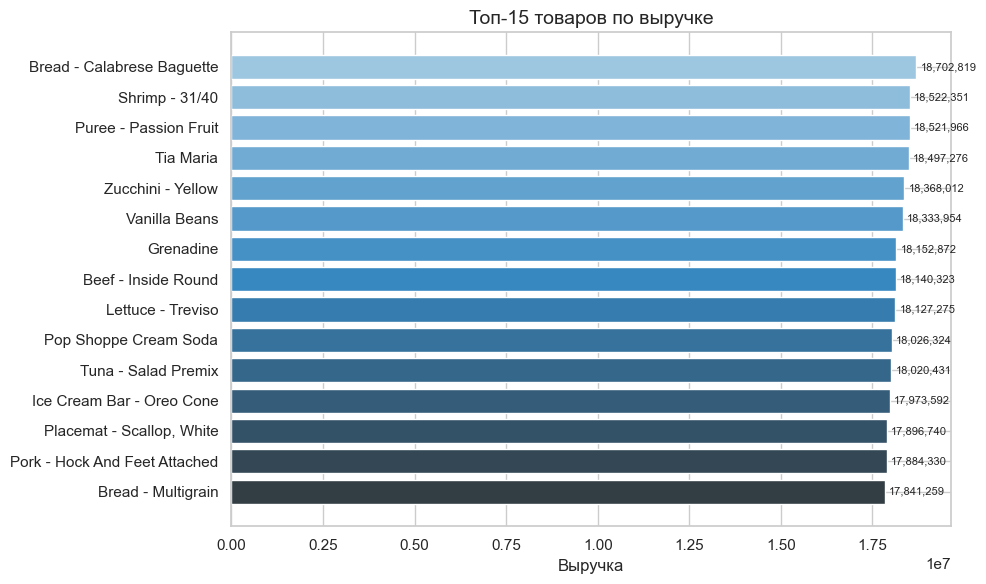

In [ ]:
# Топ товары по выручке
top15 = product_features.nlargest(15, 'total_revenue')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['product_name'], top15['total_revenue'],
               color=sns.color_palette('Blues_d', 15))
ax.invert_yaxis()
ax.set_xlabel('Выручка')
ax.set_title('Топ-15 товаров по выручке', fontsize=14)
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

---
## 10. Сохранение результатов

In [17]:
df.to_csv('df_merged.csv', index=False)
checks.to_csv('checks.csv', index=False)
customers_features.to_csv('customers_features.csv', index=False)
product_features.to_csv('product_features.csv', index=False)

print('✅ Сохранены:')
print('  df_merged.csv            — полный датасет с фичами')
print('  checks.csv               — таблица чеков')
print('  customers_features.csv   — таблица клиентов')
print('  product_features.csv     — таблица товаров')

✅ Сохранены:
  df_merged.csv            — полный датасет с фичами
  checks.csv               — таблица чеков
  customers_features.csv   — таблица клиентов
  product_features.csv     — таблица товаров


---
## 📝 Выводы по Notebook 2

| Шаг | Результат |
|-----|-----------|
| Merge | Объединены 6 таблиц в один датасет |
| Дата-фичи | year, month, day, day_of_week, quarter, week |
| Сезон | Winter / Spring / Summer / Autumn |
| Чеки | Агрегация по TransactionNumber: выручка, кол-во товаров, категорий |
| Клиенты | total_spent, avg_check, num_checks, recency и др. |
| Товары | total_revenue, num_customers, avg_discount и др. |

